# One-dimensional nonstationary example (n = 320)

Compare SGV (Vecchia GP), tgp, ResTGP(PP), and ResTGP(WN) on the same
simulated data. The mean and noise standard deviation change across four
intervals of [0, 1].

Evaluate predictions at 100 test locations using 10 independent noisy test
replicates. Report overall RMSE, CRPS, negative log predictive density,
95% coverage, and mean 95% interval width using `ResTree::restree_score()`.

Run the cells in order from a fresh R session, with this notebook's folder
as the working directory. Results and figures are saved in `output/n320`.
The final cell records the R and package versions used for the run.

## 1. Setup

In [1]:
suppressPackageStartupMessages({
  library(GpGp)
  library(tgp)
  library(ResTree)
  library(ggplot2)
  library(patchwork)
})

n <- 320
n_test <- 100
n_rep <- 10

output_dir <- "output/n320"
figure_dir <- file.path(output_dir, "figures")
dir.create(figure_dir, recursive = TRUE, showWarnings = FALSE)

theme_set(theme_bw(base_size = 15) +
  theme(legend.position = "bottom", legend.title = element_blank()))

fit_seconds <- numeric()

## 2. Simulated data

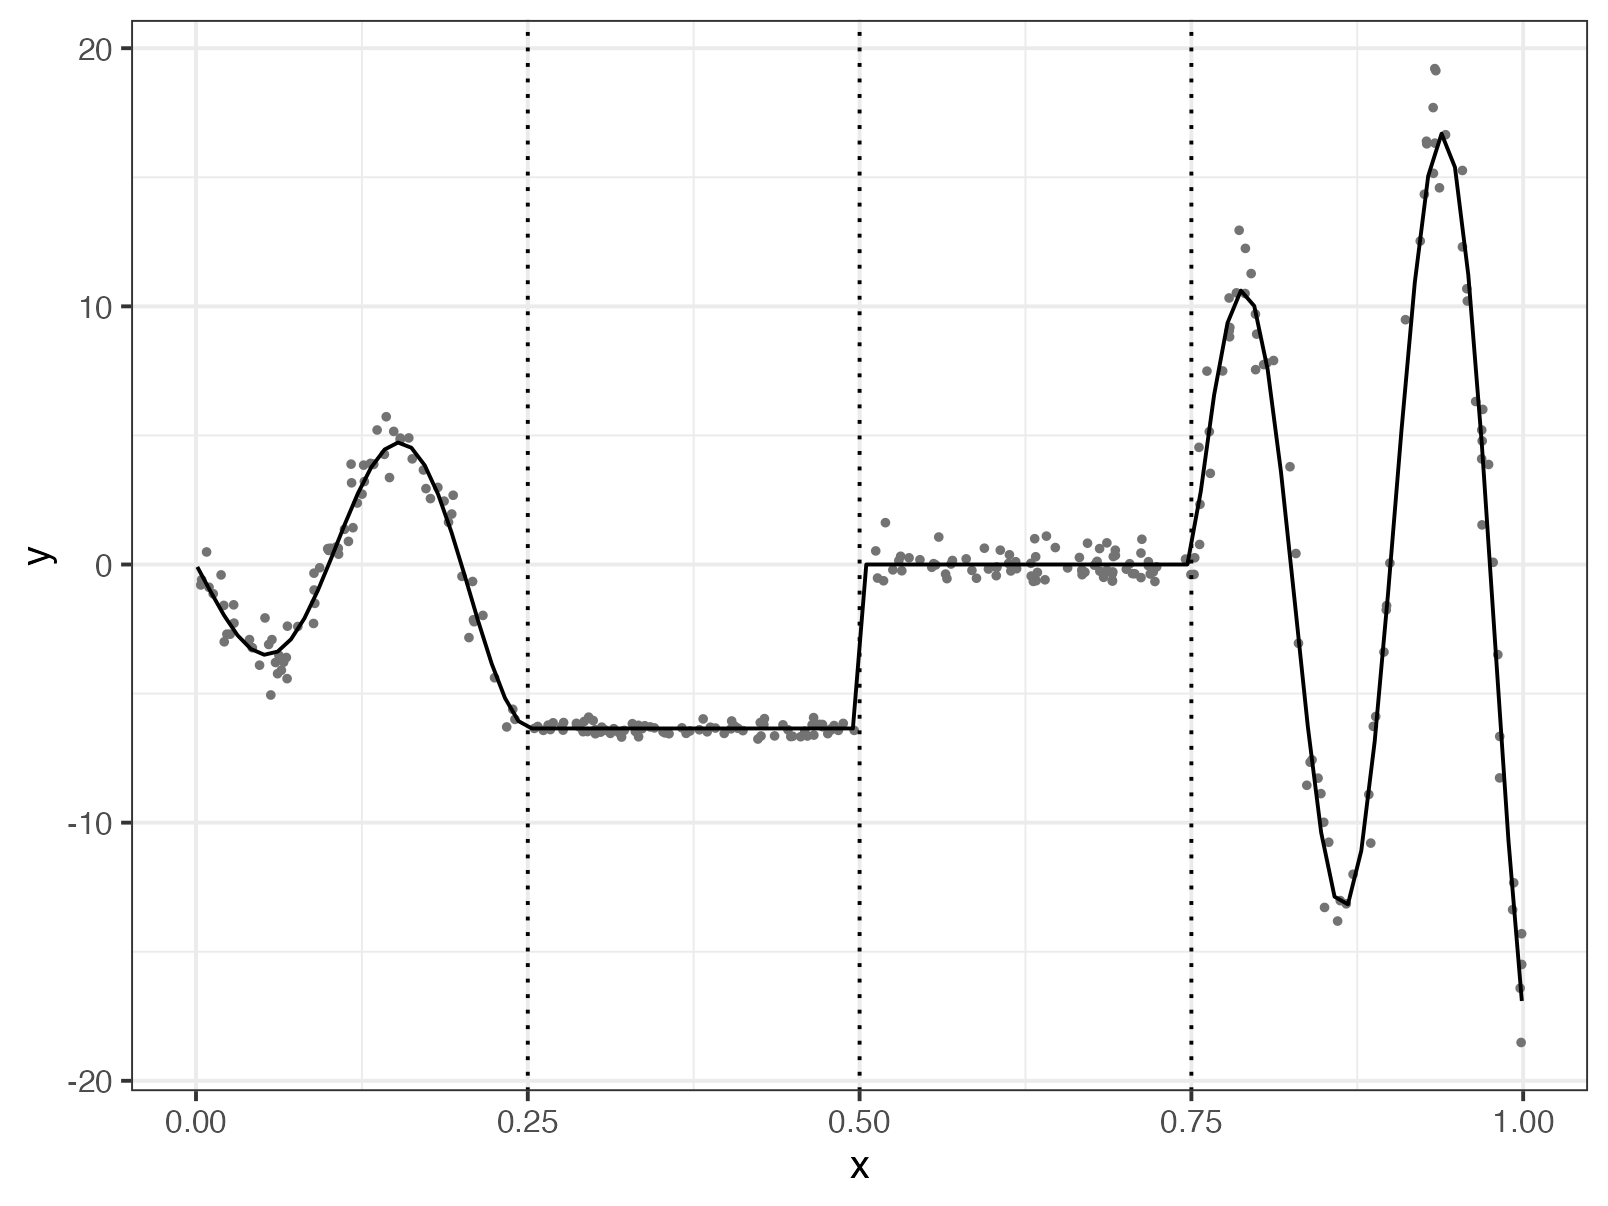

In [2]:
f_true <- function(x) {
  value <- numeric(length(x))

  i <- x <= 0.25
  value[i] <- -3 * sin(10 * pi * x[i]) * exp(3 * x[i])

  i <- x > 0.25 & x < 0.5
  value[i] <- -3 * sin(10 * pi * 0.25) * exp(3 * 0.25)

  i <- x >= 0.5 & x < 0.75
  value[i] <- sin((10 / 0.75) * pi * 0.75) * exp(3 * 0.75)

  i <- x >= 0.75
  value[i] <- sin((10 / 0.75) * pi * x[i]) * exp(3 * x[i])
  value
}

tau_true <- function(x) {
  noise_sd <- rep(1.5, length(x))
  noise_sd[x < 0.75] <- 0.5
  noise_sd[x < 0.5] <- 0.2
  noise_sd[x <= 0.25] <- 0.8
  noise_sd
}

# Draw 80 training inputs from each quarter of [0, 1].
set.seed(10)
x <- sort(unlist(lapply(1:4, function(i) {
  runif(n / 4, (i - 1) / 4, i / 4)
})))
set.seed(123)
y <- f_true(x) + tau_true(x) * rnorm(n)
X <- matrix(x, ncol = 1)

# Each column of Ynew is an independent test replicate.
xs <- seq(0.001, 0.999, length.out = n_test)
Xs <- matrix(xs, ncol = 1)
fs <- f_true(xs)
set.seed(1234)
Ynew <- fs + tau_true(xs) * matrix(rnorm(n_test * n_rep), n_test, n_rep)

p_data <- ggplot(data.frame(x, y), aes(x, y)) +
  geom_point(size = 0.8, colour = "grey45") +
  geom_line(data = data.frame(x = xs, y = fs)) +
  geom_vline(xintercept = c(0.25, 0.5, 0.75), linetype = "dotted")
ggsave(file.path(figure_dir, "fig0_data.pdf"), p_data, width = 9, height = 4.5)
p_data

## 3. SGV: Vecchia GP

In [3]:
start_time <- proc.time()[3]
fit_gp <- GpGp::fit_model(
  y, X, covfun_name = "matern25_isotropic", m_seq = 30, silent = TRUE
)
mu_gp <- GpGp::predictions(fit_gp, Xs, X_pred = matrix(1, n_test, 1), m = 30)
sd_gp <- apply(GpGp::cond_sim(
  fit_gp, Xs, X_pred = matrix(1, n_test, 1), nsims = 200, m = 30
), 1, sd)
fit_seconds["SGV"] <- proc.time()[3] - start_time

# Use the Vecchia estimates to initialize both ResTGP models.
theta0 <- restree_theta(
  sig2 = fit_gp$covparms[1],
  range = fit_gp$covparms[2],
  nugget = fit_gp$covparms[3]
)
theta0

restree_theta: matern (ARD, Euclidean)
  sig2 103.99 ; range 0.029776 ; nugget 0.0078845 ; nu 2.5

## 4. tgp

In [4]:
start_time <- proc.time()[3]
set.seed(1)
fit_tgp <- tgp::btgp(
  X, y, XX = Xs, corr = "matern", bprior = "b0", pred.n = FALSE, verb = 0
)
fit_seconds["tgp"] <- proc.time()[3] - start_time

## 5. ResTGP(PP)

In [ ]:
model_pp <- restree_model(
  X, y, r = 15, leaf_model = "PP", cut_method = "uniform",
  prior_rho = 0.05, prior_beta = 0
)
start_time <- proc.time()[3]
fit_pp <- restree_fit(
  model_pp, theta0, method = "ebayes", xnew = Xs,
  nparticles = 1000, seed = 1, ncores = 4,
  control = list(maxit = 200)
)
fit_seconds["ResTGP(PP)"] <- proc.time()[3] - start_time
fit_pp

restree fit
  method    : ebayes 
  data      : 320 observations, 1 inputs
  tree      : depth 5 ; r = 15 ; leaf model PP ; design maximin ; cuts uniform 
  theta     : sig2 93.9 ; range 0.02676 ; nugget 0.005952 ; nu 2.5 ; matern ARD 
  sigma2_hat: 93.9 (joint maximum-evidence MLE; identified noise variance sig2*nugget = 0.5589 )
  particles : 1200  (final ESS 1118) 
  log Z     : -512.25672 
  loglik    : -512.25672 
  prediction: 100 new points
  diagnostics: 1147 distinct trees; 4 resampling events; 69.3s total

## 6. ResTGP(WN)

In [83]:
model_wn <- restree_model(
  X, y, r = 15, leaf_model = "WN", cut_method = "uniform",
  prior_rho = 0.05, prior_beta = 0
)
start_time <- proc.time()[3]
fit_wn <- restree_fit(
  model_wn, theta0, method = "ebayes", xnew = Xs,
  nparticles = 1000, seed = 61, ncores = 4,
  control = list(maxit = 200)
)
fit_seconds["ResTGP(WN)"] <- proc.time()[3] - start_time
fit_wn

restree fit
  method    : ebayes 
  data      : 320 observations, 1 inputs
  tree      : depth 5 ; r = 15 ; leaf model WhiteNoise ; design maximin ; cuts uniform 
  theta     : sig2 97.25 ; range 0.02846 ; nugget 0.01256 ; nu 2.5 ; matern ARD 
  sigma2_hat: 97.25 (joint EB posterior mode; identified noise variance sig2*nugget = 1.221 )
  particles : 1000  (final ESS 315) 
  log Z     : -457.91071 
  loglik    : -457.91071 
  prediction: 100 new points
  diagnostics: 21 distinct trees; 3 resampling events; 0.635s total

## 7. Overall predictive scores

SGV and tgp are scored as Gaussian distributions using their predictive
means and variances. ResTGP uses the full mixture over trees.
`exact = TRUE, wn_leaf = "student"` retains the WN Student-t mixture;
its CRPS is evaluated by numerical integration.

Pool all 1,000 test observations in a single call per method. RMSE is
therefore the square root of the pooled mean squared error. Smaller RMSE,
CRPS, and log score are better; coverage should be close to 0.95.
Timing includes fitting and prediction, and excludes scoring.

In [84]:
predictions <- list(
  SGV = list(mean = as.numeric(mu_gp), var = as.numeric(sd_gp)^2),
  tgp = list(mean = fit_tgp$ZZ.mean, var = fit_tgp$ZZ.ks2),
  `ResTGP(PP)` = fit_pp$prediction,
  `ResTGP(WN)` = fit_wn$prediction
)
methods <- names(predictions)

observed <- as.vector(Ynew)
test_rows <- rep(seq_len(n_test), times = n_rep)

scores <- list()
for (method in methods) {
  pred <- predictions[[method]]
  pooled <- list(mean = pred$mean[test_rows], var = pred$var[test_rows])

  # Repeat each tree's predictions across replicates, keeping its weight.
  for (field in c("par_mean", "par_var", "par_df")) {
    if (!is.null(pred[[field]])) {
      pooled[[field]] <- pred[[field]][test_rows, , drop = FALSE]
    }
  }
  pooled$w <- pred$w

  scores[[method]] <- ResTree::restree_score(
    pooled, observed, label = method, exact = TRUE, 
  )
}
scores <- do.call(rbind, scores)
scores$seconds <- unname(fit_seconds[scores$method])
scores <- scores[c("method", "RMSE", "CRPS", "logscore", "cover95", "seconds")]
rownames(scores) <- NULL

#write.csv(scores, file.path(output_dir, "scores_overall.csv"), row.names = FALSE)
print(scores, digits = 3, row.names = FALSE)

     method RMSE  CRPS logscore cover95 seconds
        SGV 1.03 0.527     1.44   0.934   0.254
        tgp 1.08 0.489     1.38   0.943  32.749
 ResTGP(PP) 1.01 0.510     1.37   0.922  69.322
 ResTGP(WN) 1.02 0.484     1.08   0.932   0.642


## 8. Predictions and uncertainty

Ribbons show 95% predictive intervals; the uncertainty curve shows
`sqrt(var)`, the standard deviation of a new observation. For ResTGP,
this includes uncertainty within and between trees.

The plotting bands use two internal ResTree helpers because
`restree_score()` returns average interval width, not pointwise endpoints.
All reported metrics above use the exported scoring function.

In [85]:
curves <- list()
for (method in methods) {
  pred <- predictions[[method]]
  parts <- ResTree:::.restree_pred_parts(pred, wn_leaf = "student")
  interval <- ResTree:::.restree_predictive_quantiles(parts, c(0.025, 0.975))
  curves[[method]] <- data.frame(
    method, x = xs, mu = pred$mean, sd = sqrt(pred$var),
    lo = interval[, 1], hi = interval[, 2]
  )
}
curves <- do.call(rbind, curves)
curves$method <- factor(curves$method, levels = methods)

line_types <- c(
  SGV = "solid", tgp = "dotdash", `ResTGP(PP)` = "dashed",
  `ResTGP(WN)` = "dotted", Truth = "solid"
)

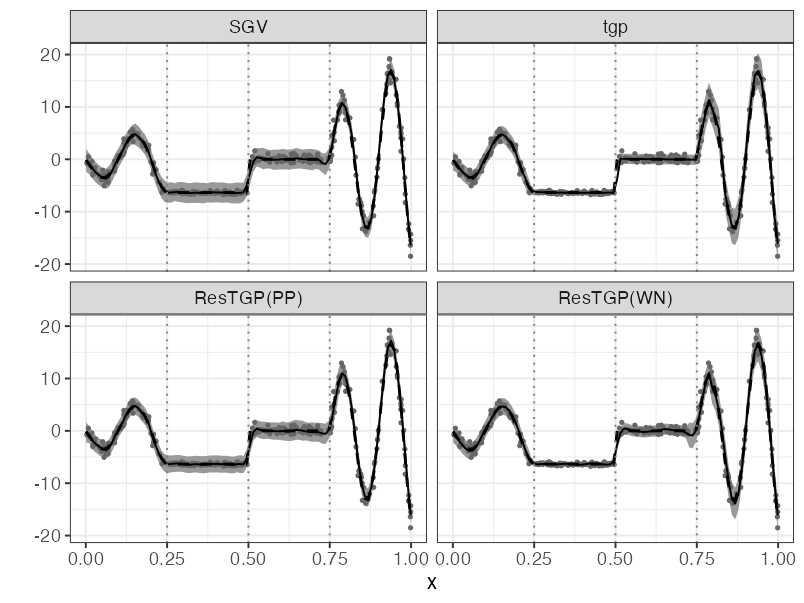

In [95]:
p_fit <- ggplot(curves, aes(x)) +
  geom_ribbon(aes(ymin = lo, ymax = hi), fill = "grey60") +
  geom_point(data = data.frame(x, y), aes(x, y), size = 1, colour = "grey40") +
  geom_line(data = data.frame(x = xs, fs), aes(y = fs), linetype = "dashed", linewidth = 1) +
  geom_line(aes(y = mu)) +
  geom_vline(xintercept = c(0.25, 0.5, 0.75), linetype = "dotted", colour = "grey50") +
  facet_wrap(~ method, ncol = 2) +
  labs(y = "") + 
  theme_bw(base_size = 15) +          
  theme(
  legend.box.spacing = unit(2, "pt"),   
  legend.margin      = margin(0, 0, 0, 0),
  legend.key.spacing = unit(16, "pt"),   
  legend.key.width   = unit(18, "pt"), 
  legend.title       = element_blank(),
  legend.position = "bottom",
    axis.title  = element_text(size = 15),
    axis.text   = element_text(size = 14),
    strip.text  = element_text(size = 14),
    legend.text  = element_text(size = 15)
  )
ggsave(file.path(figure_dir, "Sim1D_fig1_predictions.pdf"), p_fit, width = 8, height = 6)
p_fit

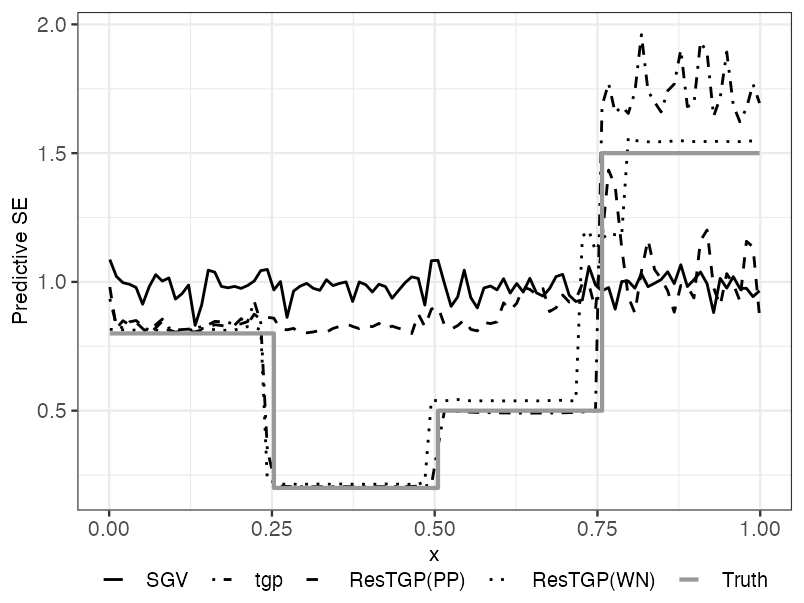

In [97]:
truth <- data.frame(x = xs, sd = tau_true(xs), method = "Truth")
p_sd <- ggplot(curves, aes(x, sd, linetype = method)) +
  geom_line(linewidth = 1) +
  geom_step(data = truth, colour = "grey60", linewidth = 1.5) +
  scale_linetype_manual(values = line_types, breaks = c(methods, "Truth")) +
  labs(y = "Predictive SE") + 
  theme_bw(base_size = 18) +          
  theme(
  legend.box.spacing = unit(2, "pt"),   
  legend.margin      = margin(0, 0, 0, 0),
  legend.key.spacing = unit(16, "pt"),   
  legend.key.width   = unit(18, "pt"), 
  legend.title       = element_blank(),
  legend.position = "bottom",
    axis.title  = element_text(size = 16),
    axis.text   = element_text(size = 16),
    strip.text  = element_text(size = 16),
    legend.text  = element_text(size = 15)
  )
ggsave(file.path(figure_dir, "Sim1D_fig2_predictive_sd.pdf"), p_sd, width = 8, height = 4)
p_sd

## 9. Software versions

Seeds are fixed above. Package versions and default settings can affect
numerical results; retain this session information with the results.

In [20]:
sessionInfo()
#writeLines(capture.output(sessionInfo()), file.path(output_dir, "sessionInfo.txt"))

R version 4.4.3 (2025-02-28)
Platform: aarch64-apple-darwin20
Running under: macOS Sequoia 15.3.2

Matrix products: default
BLAS:   /System/Library/Frameworks/Accelerate.framework/Versions/A/Frameworks/vecLib.framework/Versions/A/libBLAS.dylib 
LAPACK: /Library/Frameworks/R.framework/Versions/4.4-arm64/Resources/lib/libRlapack.dylib;  LAPACK version 3.12.0

locale:
[1] en_US.UTF-8/en_US.UTF-8/en_US.UTF-8/C/en_US.UTF-8/en_US.UTF-8

time zone: America/Chicago
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] patchwork_1.3.2 ggplot2_4.0.2   ResTree_0.1.9   tgp_2.4-23      GpGp_1.0.0     

loaded via a namespace (and not attached):
 [1] vctrs_0.7.1        cli_3.6.5          maptree_1.4-9      rlang_1.1.7        renv_1.1.8        
 [6] generics_0.1.4     dotCall64_1.2      textshaping_1.0.5  S7_0.2.1           labeling_0.4.3    
[11] glue_1.8.0         fields_17.1        ragg_1.5.1        